# Fine Res Initial

In [24]:
import os
python_path = r"C:\Users\QT3 User Facility\AppData\Local\Programs\Python\Python314\Scripts"
os.environ["PATH"] = python_path + ";" + os.environ["PATH"]

# Test
!pip --version

pip 25.3 from C:\Users\QT3 User Facility\AppData\Local\Programs\Python\Python314\Lib\site-packages\pip (python 3.14)



In [25]:
# (requires) setup.py, run to show version of qickdawg installed
!pip show qickdawg

Name: qickdawg
Version: 1.2.1
Summary: Software for full quantum control of nitrogen-vacancy defects and other quantum defects in diamond
Home-page: 
Author: 
Author-email: Andy Mounce <amounce@sandia.gov>, Emmeline Riendeau <eriendeau@uchicago.edu>
License: MIT License 

Copyright 2023 National Technology & Engineering Solutions of Sandia, LLC (NTESS). Under the terms of Contract DE-NA0003525 with NTESS, the U.S. Government retains certain rights in this software.

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substa

In [26]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from copy import copy
import qickdawg as qd

from scipy.optimize import curve_fit
from scipy.signal import find_peaks

from importlib.metadata import version
version('numpy')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'2.3.3'

In [27]:
qd.start_client('192.168.3.1')

In [28]:
from logging import config


default_config = qd.NVConfiguration()

# Channels and pmods
default_config.mw_channel = 0
default_config.adc_channel = 0
default_config.laser_gate_pmod = 0 # should be 0 for PMOD0_0

# MW pulse parameters
default_config.mw_pi_tdds = 272
default_config.mw_fMHz = 1846
default_config.mw_nqz = 1
default_config.mw_gain = 30000

# Delays
default_config.mw_to_laser_delay_tns = 555
default_config.relax_delay_tus = 3

# Readout
default_config.laser_on_tus = 5
default_config.readout_reference_start_tus = 3.5
default_config.readout_integration_tns = 350 
default_config.laser_readout_offset_tus = 1.17

# Other
default_config.reps = 10000
default_config.pre_init = True
default_config.get_reference = True

# Photon Counting Params
default_config.edge_counting = True
default_config.high_threshold = 8000
default_config.low_threshold = 500

In [29]:
qd.laser_on(copy(default_config))

0

In [30]:
qd.laser_off(copy(default_config))

0

In [ ]:
from qickdawg.nvtestsuite.counting_duration_fine_res import CountingDurationFineRes

config = copy(default_config)

config.readout_integration_tns = 10
config.reps = 400000

delays = np.arange(800, 1600, 5)

def _as_scalar(value):
    arr = np.asarray(value).squeeze()
    if arr.size == 1:
        return float(arr)
    return float(np.mean(arr))

# Basic practical fix: discard one dummy acquisition before storing data.
config.laser_readout_offset_tns = int(delays[0])
_ = CountingDurationFineRes(config).acquire()

results = None
for i in delays:
    config.laser_readout_offset_tns = int(i)

    prog = CountingDurationFineRes(config)
    d = prog.acquire()

    if results is None:
        results = copy(d)
        for key in d.keys():
            results[key] = np.array([_as_scalar(d[key])], dtype=float)
        results.delay = np.array([config.laser_readout_offset_tus], dtype=int)
    else:
        for key in d.keys():
            results[key] = np.append(results[key], _as_scalar(d[key]))
        results.delay = np.append(results.delay, config.laser_readout_offset_tus)

print(f"Stored {len(results.delay)} points.")

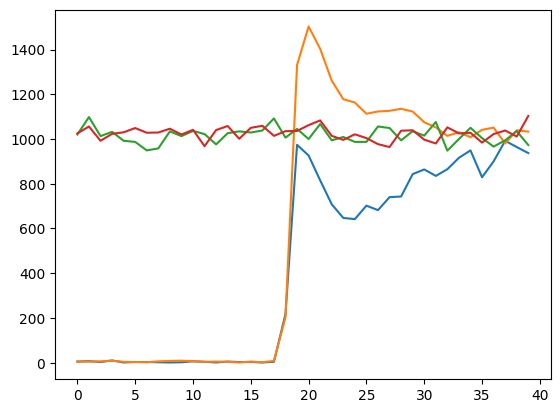

In [ ]:
plt.plot(results.signal1)
plt.plot(results.signal2)
plt.plot(results.reference1)
plt.plot(results.reference2)

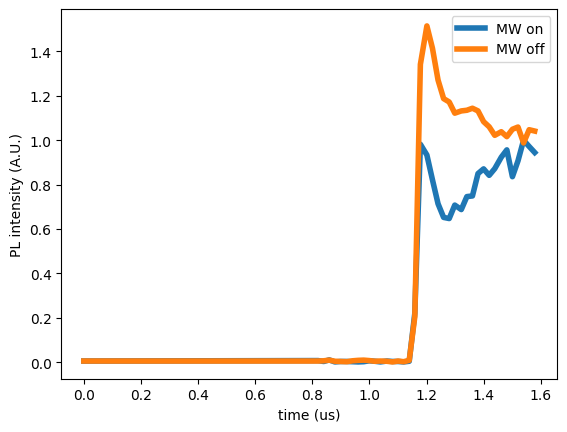

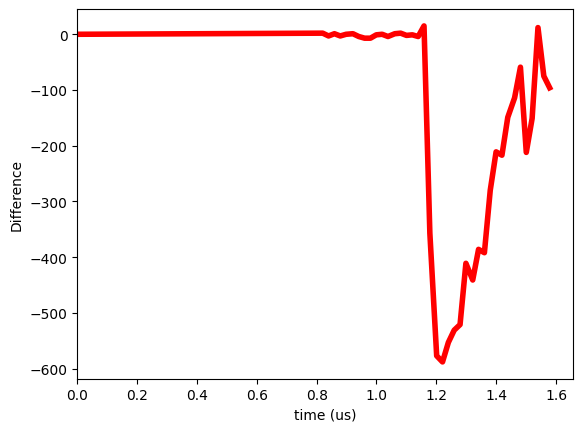

laser_readout_offset is approximately 1.178 us (362 treg)


In [ ]:
# Here we plot the readout window data for the microwave pluse on and the microwave off
data_off = results.signal2
data_on = results.signal1

t = np.array(results.delay)
x = data_on
x2 = data_off

plt.plot(t, x/np.max(x), linewidth=4)
plt.plot(t, x2/np.max(x), linewidth=4) 

plt.legend(['MW on', 'MW off'])
plt.xlabel('time (us)')
plt.ylabel('PL intensity (A.U.)')
# plt.xlim(0, 190)
# plt.ylim(0, 1.1)
plt.show()

plt.plot(t, x - x2, c='red', linewidth=4)
plt.ylabel('Difference')
plt.xlabel('time (us)')
plt.xlim(0, )
plt.show()

config.one_treg = 1
print('laser_readout_offset is approximately {} us '.format(np.round(results.delay[np.where(x/np.max(x) > 0.8)[0][0]], 3)) + 
      '({} treg)'.format(int(results.delay[np.where(x/np.max(x) > 0.8)[0][0]]/config.one_tus)))

In [ ]:
from qickdawg.nvtestsuite.rabi_fine_res import RabiFineRes

config = copy(default_config)

config.add_unitless_linear_sweep("mw_duration_tdds", 50, 3000, delta=20)
config.mw_gain = 30000
config.mw_fMHz = 1846
config.reps = int(300000/6)

prog = RabiFineRes(config)
d = prog.acquire(progress=True)


Requested 50 to 3000 by 20
Instead using 50 to 3010 by 20 in 148


100%|██████████| 7400000/7400000 [02:11<00:00, 56354.39it/s]


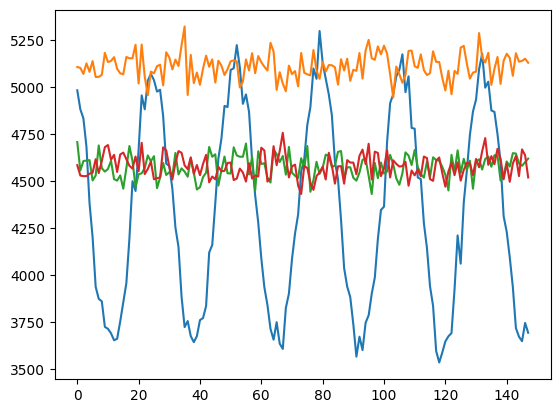

In [177]:
plt.plot(d.signal1)
plt.plot(d.signal2)
plt.plot(d.reference1)
plt.plot(d.reference2)

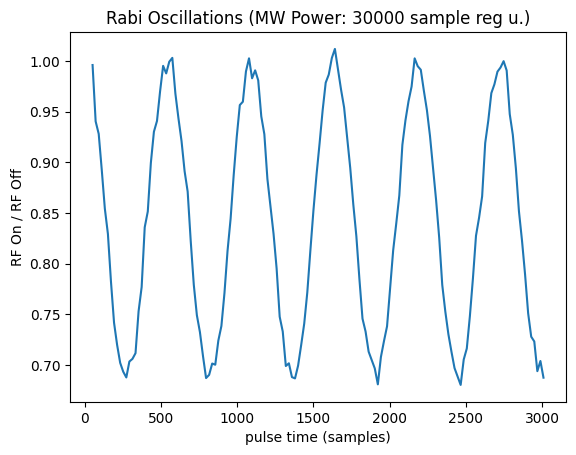

In [ ]:
plt.plot(d.sweep_treg, d.signal1/d.signal2)

plt.title(f'Rabi Oscillations (MW Power: {config.mw_gain} sample reg u.)')
plt.ylabel('RF On / RF Off')
plt.xlabel('pulse time (samples)')
plt.show()

In [8]:
import warnings
from scipy.optimize import OptimizeWarning

def decaying_cos(x, A, T, C, tau):

    return A * (np.cos(x*2*np.pi/T))*np.exp(-x/tau) + C

def no_decay_cos(x, A, T, C):
    return A * np.cos(x * 2 * np.pi / T) + C


t = np.asarray(d.sweep_treg, dtype=float)
x = np.asarray(d.signal1 / d.signal2, dtype=float)

# Try 4-parameter decaying fit first.
p0_full = [0.1, 600.0, float(np.mean(x)), 3000.0]
bounds_full = ([0.0, 100.0, 0.0, 10.0], [1.0, 5000.0, 2.0, 1e7])

use_no_decay = False
fit_reason = ""

try:
    with warnings.catch_warnings():
        warnings.simplefilter("error", OptimizeWarning)
        param4, cov4 = curve_fit(
            decaying_cos,
            t,
            x,
            p0=p0_full,
            bounds=bounds_full,
            maxfev=20000,
        )

    tau = float(param4[3])
    finite_cov = np.all(np.isfinite(cov4))
    tau_effectively_infinite = tau > 10 * (np.max(t) - np.min(t))

    if (not finite_cov) or tau_effectively_infinite:
        use_no_decay = True
        fit_reason = "tau is not identifiable (effectively no measurable decay)"
except (RuntimeError, OptimizeWarning, ValueError) as exc:
    use_no_decay = True
    fit_reason = f"4-parameter fit failed: {exc}"

if use_no_decay:
    p0_3 = [0.1, 600.0, float(np.mean(x))]
    bounds_3 = ([0.0, 100.0, 0.0], [1.0, 5000.0, 2.0])
    param3, cov3 = curve_fit(
        no_decay_cos,
        t,
        x,
        p0=p0_3,
        bounds=bounds_3,
        maxfev=20000,
    )
    yfit = no_decay_cos(t, *param3)
    print(f"Using 3-parameter no-decay fit ({fit_reason}).")
    print("[A, T, C] =", param3)
    period_samples = float(param3[1])
else:
    yfit = decaying_cos(t, *param4)
    print("Using 4-parameter decaying fit.")
    print("[A, T, C, tau] =", param4)
    period_samples = float(param4[1])

plt.plot(t, x, label="Data", linewidth=2)
plt.plot(t, yfit, label="Best fit", linewidth=3)
plt.title(f"Rabi Oscillations (MW Power: {config.mw_gain} reg u.)")
plt.ylabel("RF On / RF Off")
plt.xlabel("time (samples)")
plt.xlim(0, np.max(t))
plt.ylim(np.min(x) - 0.01, np.max(x) + 0.01)
plt.legend()
plt.show()

print(f"Pi/2 pulse is approximately {period_samples / 4:.2f} samples")

NameError: name 'd' is not defined

In [ ]:
from qickdawg.nvtestsuite.podmr_fine_res import PODMRFineRes

config = copy(default_config)

center = config.mw_fMHz
width = 7
config.add_linear_sweep('mw', 'fMHz', start=center-width, stop=center+width, delta=0.2)

config.reps = int(300000/6)

prog = PODMRFineRes(config)
d = prog.acquire(progress=True)


Requested 1838.9999996185302 to 1852.9999996185302 by 0.2
Instead using 1839.0 to 1853.0000267028809 by 0.20000038146972654 in 71 steps


100%|██████████| 2130000/2130000 [00:36<00:00, 58049.46it/s]


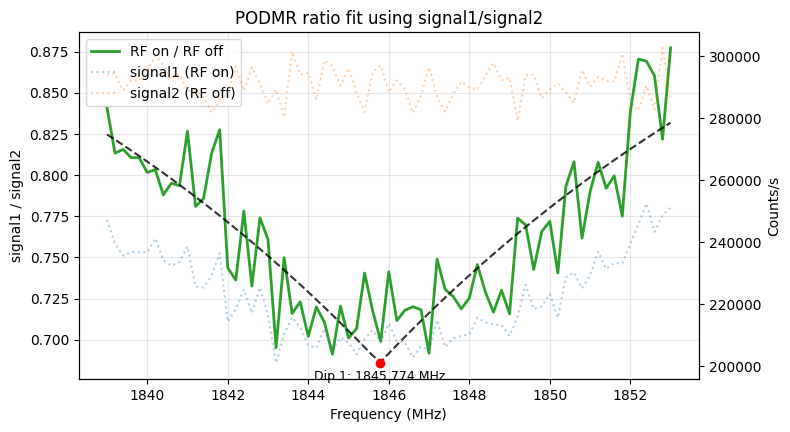

Fitted dip centers (MHz): [1845.773723]


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

# Number of dips to fit in RF/no-RF ratio trace.
num_dips = 1

if "d" not in globals():
    raise RuntimeError("No data object 'd' found. Run the acquisition cell first.")

# Use PODMR outputs directly.
rf_counts = np.asarray(d.signal1, dtype=float)      # RF on counts/s
no_rf_counts = np.asarray(d.signal2, dtype=float)   # RF off counts/s
freq = np.asarray(getattr(d, "frequencies", np.arange(rf_counts.size)), dtype=float)

if rf_counts.shape != no_rf_counts.shape:
    raise ValueError(f"signal1 and signal2 shape mismatch: {rf_counts.shape} vs {no_rf_counts.shape}")

if freq.shape[0] != rf_counts.shape[0]:
    raise ValueError("Frequency axis length does not match signal length.")

ratio = rf_counts / np.clip(no_rf_counts, 1e-12, None)


def laplace_dip_model(x, depth, mu, b, C):
    # depth > 0, b > 0 so the model is a dip on top of baseline C.
    return C - depth * np.exp(-np.abs(x - mu) / b)


def fit_single_dip(freq_axis, y, mu_guess):
    span = float(np.max(freq_axis) - np.min(freq_axis))
    y_min = float(np.min(y))
    y_max = float(np.max(y))
    C0 = float(np.median(y))
    depth0 = max(C0 - y_min, 1e-4)
    b0 = max(span / 30.0, 1e-6)

    p0 = [depth0, float(mu_guess), b0, C0]
    bounds = ([1e-7, float(np.min(freq_axis)), 1e-7, y_min - 0.5],
              [max(2.0, 5 * depth0), float(np.max(freq_axis)), span, y_max + 0.5])

    popt, _ = curve_fit(
        laplace_dip_model,
        freq_axis,
        y,
        p0=p0,
        bounds=bounds,
        maxfev=20000,
    )
    return popt


# Find candidate dip positions from inverted ratio.
inverted = np.max(ratio) - ratio
peak_idxs, _ = find_peaks(inverted, distance=max(1, len(inverted) // (num_dips + 1)))

if peak_idxs.size == 0:
    peak_idxs = np.array([int(np.argmin(ratio))])

# Rank candidates by dip depth and fit top N.
candidate_order = np.argsort(ratio[peak_idxs])
selected = peak_idxs[candidate_order[:num_dips]]
selected = np.sort(selected)

fit_params = []
fit_freqs = []
for idx in selected:
    params = fit_single_dip(freq, ratio, freq[idx])
    fit_params.append(params)
    fit_freqs.append(float(params[1]))

# Plot ratio and fits.
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(freq, ratio, color="tab:green", linewidth=2, label="RF on / RF off")

for i, params in enumerate(fit_params, start=1):
    fit_curve = laplace_dip_model(freq, *params)
    depth, mu, b, C = params
    ax.plot(freq, fit_curve, "--", color="black", alpha=0.8)
    ax.plot(mu, C - depth, "ro")
    ax.annotate(
        f"Dip {i}: {mu:.3f} MHz",
        xy=(mu, C - depth),
        xytext=(0, -12),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

ax.set_title("PODMR ratio fit using signal1/signal2")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("signal1 / signal2")
ax.grid(alpha=0.3)

# Show raw count traces on a secondary axis for context.
ax2 = ax.twinx()
ax2.plot(freq, rf_counts, color="tab:blue", alpha=0.35, linestyle=":", label="signal1 (RF on)")
ax2.plot(freq, no_rf_counts, color="tab:orange", alpha=0.35, linestyle=":", label="signal2 (RF off)")
ax2.set_ylabel("Counts/s")

# Combined legend.
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="best")

plt.show()

print("Fitted dip centers (MHz):", [round(f, 6) for f in fit_freqs])